In [1]:
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt
import pickle
from joblib import Parallel, delayed

In [2]:
from rc import ESN, ESNConfig

In [42]:
pendulum_data = np.load('../results_data/s_resampled.npy').T

In [43]:
pendulum_data.shape

(4, 50000)

In [5]:
dt = 0.1

In [ ]:
dt_orig = 0.001
resample_factor = int(dt / dt_orig)

In [371]:
pendulum_data = pendulum_data[:2, ::resample_factor][:, :]

In [410]:
pendulum_data.shape

(4, 5000000)

In [5]:
dts = np.linspace(0.01, 0.1, 10)

In [430]:
config = ESNConfig(
    N=700,
    input_dim=2,
    spectral_radius=0.1,
    alpha=9.73476523974807e-07,
    sparsity=0.99,
    input_scaling=1,
    bias_scaling=0.1,
    seed=None,
    mode="leaky",
    leaky_rate=0.06402723031574233,
)

In [404]:
esn = ESN(config)
esn.train(pendulum_data, washout=10000)

In [406]:
lyapunov_spectrum = esn.lyapunov_spectrum(pendulum_data,
                                        num_lyaps=4,
                                        steps=5000,
                                        norm_time=2,
                                        dt=dt,
                                        num_samples=5,
                                        warmup=2000,
                                        transient=1000)


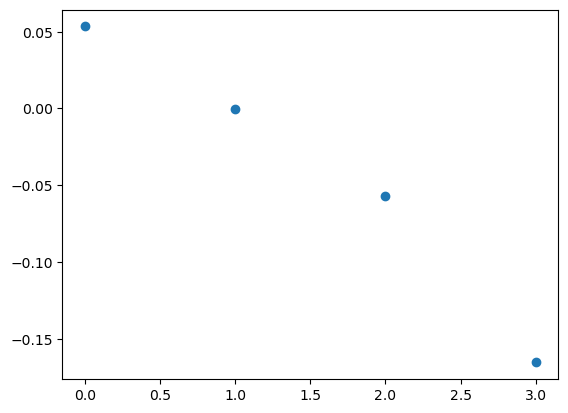

In [407]:
plt.plot(lyapunov_spectrum['mean'][:4], 'o')

In [431]:

def compute_spectrum(dt, i, dt_orig, pendulum_data, config):
    print(f"Computing dt={dt}, iteration={i}")
    resample_factor = int(dt / dt_orig)
    train_data = pendulum_data[:2, ::resample_factor][:, :]
    
    washout_scaled = int(2000 * (10 / resample_factor))
    steps_scaled = int(4000 * (10 / resample_factor))
    
    config_copy = ESNConfig(
        N=config.N,
        input_dim=config.input_dim,
        spectral_radius=config.spectral_radius,
        alpha=config.alpha,
        sparsity=config.sparsity,
        input_scaling=config.input_scaling,
        bias_scaling=config.bias_scaling,
        seed=config.seed,
        mode=config.mode,
        leaky_rate=config.leaky_rate,
    )
    esn = ESN(config_copy)
    esn.train(train_data, washout=washout_scaled)
    lyapunov_spectrum = esn.lyapunov_spectrum(train_data,
                                        num_lyaps=8,
                                        steps=steps_scaled,
                                        norm_time=2,
                                        dt=dt,
                                        num_samples=5,
                                        warmup=2000,
                                        transient=1000)
    return lyapunov_spectrum

spctrums = []

for dt in dts:
    spectrum_within_dt = Parallel(n_jobs=-2)(
        delayed(compute_spectrum)(dt, i, dt_orig, pendulum_data, config) 
        for i in range(10)
    )
    spctrums.append(spectrum_within_dt)
    print(f"Completed dt={dt}, mean: {spectrum_within_dt[0]['mean']}")
    

Computing dt=0.01, iteration=8
Computing dt=0.01, iteration=2
Computing dt=0.01, iteration=6
Computing dt=0.01, iteration=3
Computing dt=0.01, iteration=0
Computing dt=0.01, iteration=7
Computing dt=0.01, iteration=4
Computing dt=0.01, iteration=1Computing dt=0.01, iteration=5

Computing dt=0.01, iteration=9
Completed dt=0.01, mean: [ 5.18454283e-02 -1.99725806e-03 -6.19797267e-02 -8.62715448e-02
 -5.31610464e+00 -5.71070938e+00 -6.06001614e+00 -6.11512669e+00]
Computing dt=0.020000000000000004, iteration=5
Computing dt=0.020000000000000004, iteration=4
Computing dt=0.020000000000000004, iteration=3
Computing dt=0.020000000000000004, iteration=8
Computing dt=0.020000000000000004, iteration=1
Computing dt=0.020000000000000004, iteration=7
Computing dt=0.020000000000000004, iteration=2
Computing dt=0.020000000000000004, iteration=0
Computing dt=0.020000000000000004, iteration=6
Computing dt=0.020000000000000004, iteration=9
Completed dt=0.020000000000000004, mean: [ 0.11754196  0.0121819

In [ ]:

with open('../results_data/spctrums_dp_pendulum.pkl', 'wb') as f:
    pickle.dump(spctrums, f)


In [3]:
with open('../results_data/spctrums_dp_pendulum.pkl', 'rb') as f:
    spctrums = pickle.load(f)

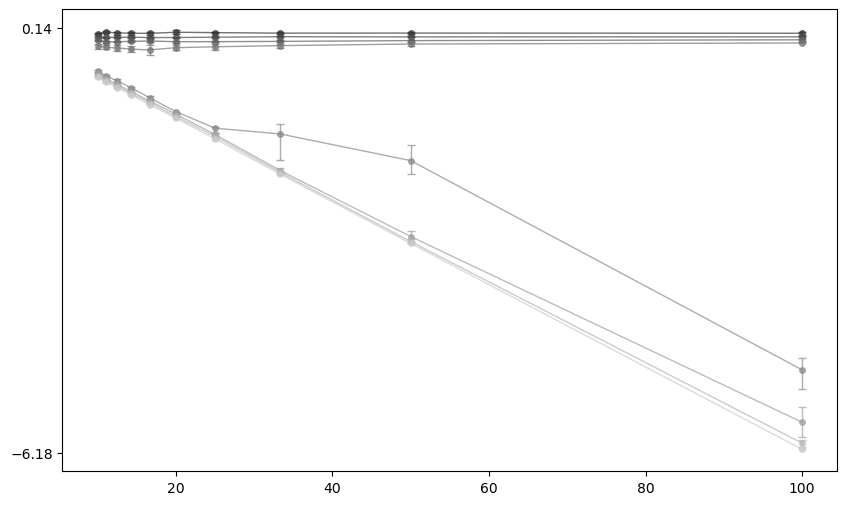

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

num_exponents = len(spctrums[0][0]["mean"])

colors = plt.cm.gray(np.linspace(0.2, 0.8, num_exponents))

def bootstrap_ci(data, n_bootstrap=1000, ci=95):
    bootstrap_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        bootstrap_means.append(np.median(sample))
    lower = np.percentile(bootstrap_means, (100 - ci) / 2)
    upper = np.percentile(bootstrap_means, 100 - (100 - ci) / 2)
    return lower, upper

for exponent_idx in range(num_exponents):
    inv_dts = [1/dt for dt in dts]
    exponent_values = [
        np.mean([spectrum["mean"][exponent_idx] for spectrum in spectrum_list])
        for spectrum_list in spctrums
    ]
    exponent_errors_lower = []
    exponent_errors_upper = []
    for spectrum_list in spctrums:
        data = [spectrum["mean"][exponent_idx] for spectrum in spectrum_list]
        lower, upper = bootstrap_ci(data)
        mean_val = np.mean(data)
        exponent_errors_lower.append(abs(mean_val - lower))
        exponent_errors_upper.append(abs(upper - mean_val))
    
    exponent_errors = [exponent_errors_lower, exponent_errors_upper]
    ax.errorbar(inv_dts, exponent_values, yerr=exponent_errors, marker='o', markersize=4, linewidth=1, alpha=0.7, capsize=3, color=colors[exponent_idx], label=f'λ_{exponent_idx+1}')


ax.set_yticks([min([min([spectrum["mean"][i] for spectrum in spectrum_list]) for spectrum_list in spctrums for i in range(num_exponents)]), 
               max([max([spectrum["mean"][i] for spectrum in spectrum_list]) for spectrum_list in spctrums for i in range(num_exponents)])])
ax.minorticks_off()


plt.show()


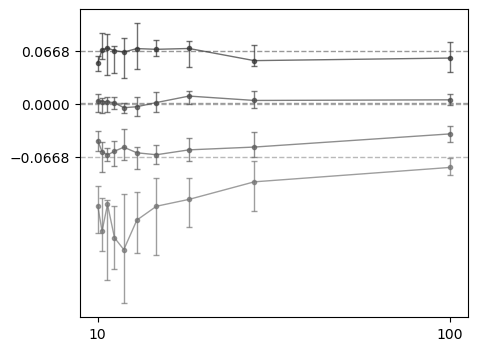

In [434]:
fig, ax = plt.subplots(figsize=(5, 4))

for exponent_idx in range(4):
    inv_dts = [1/dt for dt in dts]
    exponent_values = [
        np.median([spectrum["mean"][exponent_idx] for spectrum in spectrum_list])
        for spectrum_list in spctrums
    ]
    exponent_errors_lower = []
    exponent_errors_upper = []
    for spectrum_list in spctrums:
        data = [spectrum["mean"][exponent_idx] for spectrum in spectrum_list]
        lower, upper = bootstrap_ci(data)
        mean_val = np.median(data)
        exponent_errors_lower.append(mean_val - lower)
        exponent_errors_upper.append(upper - mean_val)
    
    exponent_errors = [exponent_errors_lower, exponent_errors_upper]
    ax.errorbar(inv_dts, exponent_values, yerr=exponent_errors, marker='o', markersize=3, linewidth=1, alpha=0.7, capsize=2, color=colors[exponent_idx])

real_lyapunov = [0.06679198, 0.00059611, -0.00055851, -0.06684586]
for exponent_idx in range(4):
    ax.axhline(y=real_lyapunov[exponent_idx], linestyle='--', linewidth=1, alpha=0.5, color=colors[exponent_idx])

ax.set_xticks([min(inv_dts), max(inv_dts)])
ax.set_yticks([real_lyapunov[-1], 0, real_lyapunov[0]])
ax.minorticks_off()
plt.savefig('supplemend_dt_pendulum.svg', format='svg', bbox_inches='tight')
plt.savefig('supplemend_dt_pendulum.pdf', format='pdf', bbox_inches='tight')
plt.show()


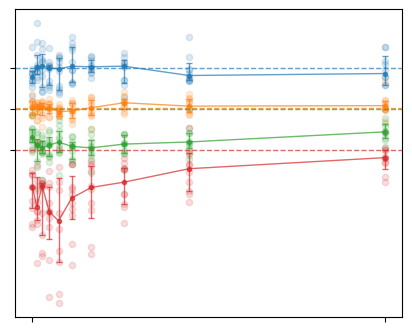

In [15]:
fig, ax = plt.subplots(figsize=(5, 4))

colors = ['C0', 'C1', 'C2', 'C3']

for exponent_idx in range(4):
    inv_dts = [1/dt for dt in dts]
    color = colors[exponent_idx]
    
    # Scatter individual data points
    for dt_idx, spectrum_list in enumerate(spctrums):
        inv_dt = inv_dts[dt_idx]
        exponent_values = [spectrum["mean"][exponent_idx] for spectrum in spectrum_list]
        ax.scatter([inv_dt] * len(exponent_values), exponent_values, s=20, alpha=0.15, color=color)
    
    # Plot median values with error bars
    exponent_values = [
        np.median([spectrum["mean"][exponent_idx] for spectrum in spectrum_list])
        for spectrum_list in spctrums
    ]
    exponent_errors_lower = []
    exponent_errors_upper = []
    for spectrum_list in spctrums:
        data = [spectrum["mean"][exponent_idx] for spectrum in spectrum_list]
        lower, upper = bootstrap_ci(data)
        mean_val = np.median(data)
        exponent_errors_lower.append(mean_val - lower)
        exponent_errors_upper.append(upper - mean_val)
    
    exponent_errors = [exponent_errors_lower, exponent_errors_upper]
    ax.errorbar(inv_dts, exponent_values, yerr=exponent_errors, marker='o', markersize=3, linewidth=1, alpha=0.7, capsize=2, color=color)

real_lyapunov = [0.06679198, 0.00059611, -0.00055851, -0.06684586]
for exponent_idx in range(4):
    ax.axhline(y=real_lyapunov[exponent_idx], linestyle='--', linewidth=1, alpha=0.7, color=colors[exponent_idx])

ax.set_xticks([min(inv_dts), max(inv_dts)])
ax.set_xticklabels([])
ax.set_yticks([real_lyapunov[-1], 0, real_lyapunov[0]])
ax.set_yticklabels([])
ax.minorticks_off()
plt.savefig('supplemend_dt_pendulum.svg', format='svg', bbox_inches='tight')
plt.savefig('supplemend_dt_pendulum.pdf', format='pdf', bbox_inches='tight')
plt.show()
